# Evaluación Parcial 1
## Exploración y Preprocesamiento de Datos

**Asignatura:** Machine Learning - TLY1101  
**Caso:** Predicción de Abandono de Clientes - Telco Customer Churn  

### Contexto

Una empresa de telecomunicaciones busca comprender los factores asociados al abandono de sus clientes con el propósito de apoyar futuras estrategias de retención.

El objetivo de esta etapa es realizar la exploración y el preprocesamiento del conjunto de datos **Telco Customer Churn**, preparando la información para posteriormente utilizarla en modelos de Machine Learning.

La variable objetivo del problema es **Churn**, que indica si un cliente abandonó o no la compañía.

### Importación de librerías

*Se importan las bibliotecas necesarias para realizar la exploración, limpieza, transformación y preprocesamiento del conjunto de datos.*

In [ ]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder 

In [11]:
#cargamos la bd
df=pd.read_csv('Telco_Customer_Churn_Dataset.csv')
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])
print(df.info())
df.head(2)

Cantidad de filas: 7043
Cantidad de columnas: 21
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  Pape

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [15]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.describe(include="object")

/tmp/ipykernel_11110/3714501298.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [14]:
#revisar datos duplicados
df.duplicated().sum()

np.int64(0)

### Revisión de registros duplicados

No se hallaron registros duplicados en el conjunto de datos. Por ende no es necesario eliminar observaciones por duplicidad.

### Conclusión de la exploración inicial

El conjunto de datos contiene 7.043 registros y 21 variables. La variable objetivo es `Churn`, correspondiente a un problema de clasificación binaria.

Durante la revisión inicial se identificaron variables numéricas y categóricas. Además, se observó que `TotalCharges` está almacenada como tipo `object`, a pesar de representar un valor monetario, por lo que será necesario convertirla a una variable numérica antes de continuar con el análisis.

No se detectaron registros completamente duplicados.

## 4. Detección y tratamiento de valores faltantes

Durante la exploración inicial se identificó que la variable `TotalCharges` está almacenada como tipo `object`, aunque representa un monto monetario.

Por esta razón, se transforma a tipo numérico. Los valores que no puedan convertirse correctamente serán transformados en valores faltantes (`NaN`) para posteriormente analizarlos.

In [21]:
#detectamos los valores faltantes y reemplazamos los valores no numéricos con NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].dtype
df["TotalCharges"].isnull().sum()

np.int64(11)

In [26]:
faltantes = pd.DataFrame({"Cantidad": df.isnull().sum(),})
faltantes[faltantes["Cantidad"] > 0]

,Cantidad
TotalCharges,11


In [ ]:
#analizamos los 11 registros
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
#ponemos los registros con TotalCharges nulos en un nuevo dataframe para analizarlos
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


### Análisis de valores faltantes

Se identificaron 11 valores faltantes en la variable `TotalCharges`, equivalentes aproximadamente al 0,16% del total de registros.

Al revisar estas observaciones se detectó que todos los clientes afectados presentan `tenure = 0`. Debido a que la cantidad de registros faltantes es muy pequeña respecto del tamaño total del conjunto de datos, se decide eliminar estas observaciones.

Esta decisión permite evitar una imputación artificial y mantiene prácticamente intacto el tamaño del conjunto de datos.

In [32]:
#creamos una copia del dataframe original para trabajar con ella y no perder los datos originales
df_2 = df.copy()
df = df.dropna(subset=["TotalCharges"]).copy()

In [ ]:
print("Registros antes:", len(df_2))
print("Registros después:", len(df))
print("Registros eliminados:", len(df_2) - len(df))
#verificamos que no hay valores nulos en el dataframe
df.isnull().sum().sum()

Registros antes: 7043
Registros después: 7032
Registros eliminados: 11


np.int64(0)

## 5. Detección de valores atípicos

Para identificar posibles valores atípicos en las variables numéricas continuas se utilizará el método del rango intercuartílico (IQR), complementado mediante diagramas de caja (boxplots).

Se consideran valores atípicos aquellos que se encuentran por debajo de:

Q1 - 1.5 × IQR

o por encima de:

Q3 + 1.5 × IQR

In [35]:
variables_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

Para el análisis de valores atípicos se consideran `tenure`, `MonthlyCharges` y `TotalCharges`, ya que representan variables numéricas cuantitativas.

La variable `SeniorCitizen`, aunque está almacenada numéricamente, corresponde a una característica binaria (0 = No, 1 = Sí), por lo que no se analiza como una variable continua.

/tmp/ipykernel_11110/2318178687.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[columna], vert=False)


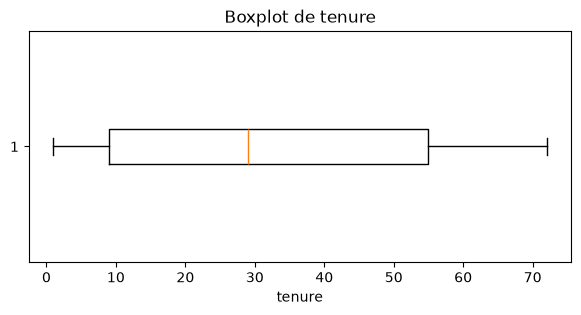

/tmp/ipykernel_11110/2318178687.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[columna], vert=False)


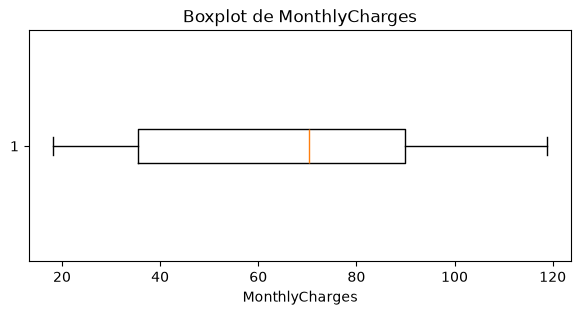

/tmp/ipykernel_11110/2318178687.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[columna], vert=False)


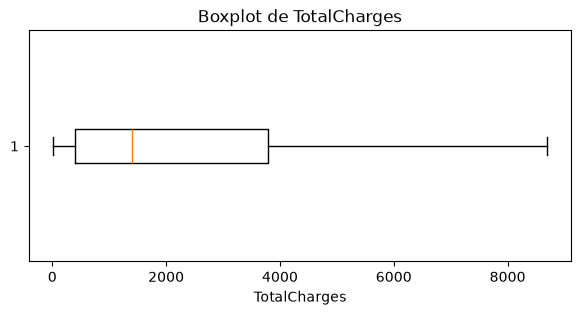

In [36]:
for columna in variables_numericas:
    plt.figure(figsize=(7, 3))
    plt.boxplot(df[columna], vert=False)
    plt.title(f"Boxplot de {columna}")
    plt.xlabel(columna)
    plt.show()

In [37]:
for columna in variables_numericas:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print(f"\nVariable: {columna}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Cantidad de outliers: {len(outliers)}")


Variable: tenure
Q1: 9.00
Q3: 55.00
IQR: 46.00
Límite inferior: -60.00
Límite superior: 124.00
Cantidad de outliers: 0

Variable: MonthlyCharges
Q1: 35.59
Q3: 89.86
IQR: 54.27
Límite inferior: -45.82
Límite superior: 171.27
Cantidad de outliers: 0

Variable: TotalCharges
Q1: 401.45
Q3: 3794.74
IQR: 3393.29
Límite inferior: -4688.48
Límite superior: 8884.67
Cantidad de outliers: 0


### Conclusión del análisis de valores atípicos

Se analizaron las variables `tenure`, `MonthlyCharges` y `TotalCharges` utilizando el criterio del rango intercuartílico (IQR) y diagramas de caja.

Según los límites calculados, no se identificaron observaciones que puedan ser clasificadas como valores atípicos mediante este criterio.

Por esta razón, no se eliminaron ni modificaron registros por valores atípicos. Esta decisión evita alterar innecesariamente información válida del conjunto de datos.

In [40]:
#comparamos las estadísticas descriptivas antes y después de eliminar los registros con valores nulos en TotalCharges
comparacion = pd.DataFrame({
    "Antes": df_2["TotalCharges"].describe(),
    "Después": df["TotalCharges"].describe()
})

comparacion

,Antes,Después
count,7032.000000,7032.000000
mean,2283.300441,2283.300441
std,2266.771362,2266.771362
min,18.800000,18.800000
25%,401.450000,401.450000
50%,1397.475000,1397.475000
75%,3794.737500,3794.737500
max,8684.800000,8684.800000


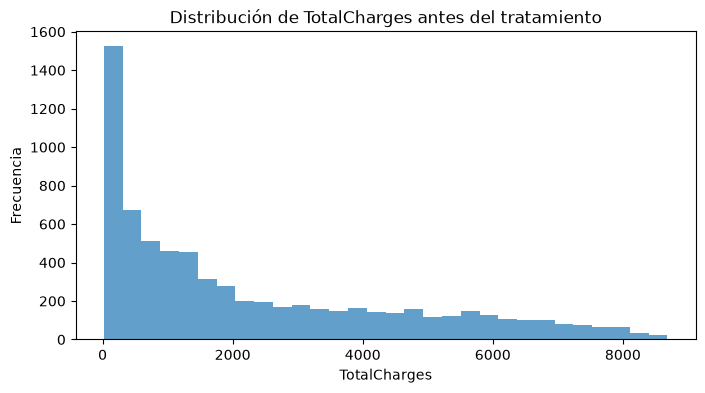

In [42]:
#graficamos la distribución de TotalCharges antes del tratamiento de valores nulos
plt.figure(figsize=(8, 4))
plt.hist(
    df_2["TotalCharges"].dropna(),
    bins=30,
    alpha=0.7
)
plt.title("Distribución de TotalCharges antes del tratamiento")
plt.xlabel("TotalCharges")
plt.ylabel("Frecuencia")
plt.show()

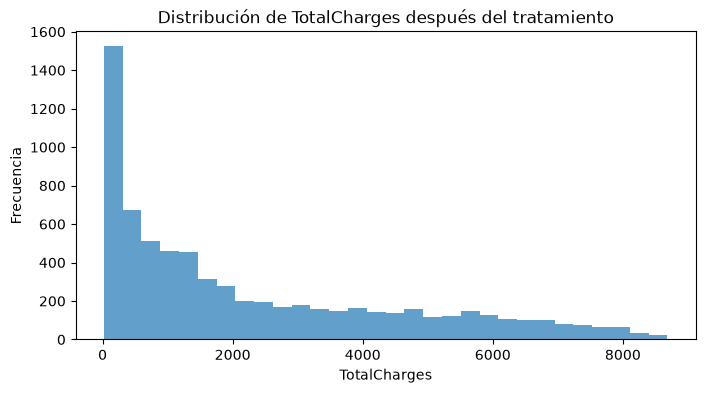

In [ ]:
#graficamos la distribución de TotalCharges después del tratamiento de valores nulos
plt.figure(figsize=(8, 4))
plt.hist(
    df["TotalCharges"],
    bins=30,
    alpha=0.7
)
plt.title("Distribución de TotalCharges después del tratamiento")
plt.xlabel("TotalCharges")
plt.ylabel("Frecuencia")
plt.show()

### Evaluación del efecto del tratamiento

El tratamiento de valores faltantes eliminó 11 registros de un total inicial de 7.043, equivalente aproximadamente al 0,16% del conjunto de datos.

Al comparar las estadísticas descriptivas y la distribución de `TotalCharges` antes y después del tratamiento, no se observan cambios significativos en su comportamiento general.

Por lo tanto, se considera que la eliminación de estos registros tuvo un impacto mínimo sobre la distribución del conjunto de datos y permitió obtener una base sin valores faltantes para continuar con el preprocesamiento.